In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Specify the GPU you want to use

In [66]:
import torch
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests

import numpy as np

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
# url = "https://www.hartz.com/wp-content/uploads/2022/04/small-dog-owners-1.jpg"
# url = "https://news.harvard.edu/wp-content/uploads/2023/11/dog_brains_2500.png?resize=1024,576"
# url = "https://i.guim.co.uk/img/media/ba55356947303677d52fb6f6239d033fb17f1aab/0_0_2539_2032/master/2539.jpg?width=965&dpr=1&s=none&crop=none"
# url = "https://hips.hearstapps.com/hmg-prod/images/small-dogs-6626cf74dfe17.jpg?crop=1xw:0.84375xh;center,top&resize=1200:*"

# url = "https://hips.hearstapps.com/hmg-prod/images/woman-with-dog-outside-1558449251.jpg?crop=0.680xw:1.00xh;0,0&resize=980:*"




image = Image.open(requests.get(url, stream=True).raw)

processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
model = AutoModel.from_pretrained('facebook/dinov2-base')



In [67]:
print(image.size)
# image.show()

(640, 480)


In [68]:
model

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06,

In [80]:
inputs = processor(images=image, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
    
    features = outputs.last_hidden_state
    print(attentions)

None


In [69]:

# outputs = model(**inputs)
# features = outputs.last_hidden_state
# print(features)

tensor([[[-2.2005, -0.4495,  1.0964,  ...,  0.2113,  1.1496,  0.1267],
         [-3.3959, -0.8942, -1.0315,  ...,  1.4867, -0.5316, -0.9317],
         [-2.9355,  1.1564, -0.7656,  ...,  0.6501, -1.9041, -2.3671],
         ...,
         [-0.4961,  1.3416, -0.2869,  ...,  0.2186, -2.9740,  0.5224],
         [-3.0983,  2.0505,  1.4553,  ...,  0.7989, -2.6633,  2.2196],
         [-0.6799,  0.0304,  1.4230,  ..., -0.3459, -2.4010, -0.1477]]],
       grad_fn=<NativeLayerNormBackward0>)


In [79]:
outputs

BaseModelOutputWithPooling(last_hidden_state=tensor([[[-2.2005, -0.4495,  1.0964,  ...,  0.2113,  1.1496,  0.1267],
         [-3.3959, -0.8942, -1.0315,  ...,  1.4867, -0.5316, -0.9317],
         [-2.9355,  1.1564, -0.7656,  ...,  0.6501, -1.9041, -2.3671],
         ...,
         [-0.4961,  1.3416, -0.2869,  ...,  0.2186, -2.9740,  0.5224],
         [-3.0983,  2.0505,  1.4553,  ...,  0.7989, -2.6633,  2.2196],
         [-0.6799,  0.0304,  1.4230,  ..., -0.3459, -2.4010, -0.1477]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[-2.2005e+00, -4.4949e-01,  1.0964e+00, -1.3291e+00, -2.9672e-02,
          7.5587e-01, -1.5447e-02,  1.5769e+00, -1.9610e+00,  2.4383e+00,
         -4.3804e-01, -1.3045e+00,  1.1043e+00,  1.4173e+00, -9.2580e-01,
         -1.6590e+00,  2.3838e+00,  5.3868e-02, -8.6848e-02,  1.9271e+00,
          3.9997e-01, -1.2583e+00, -2.9034e+00,  2.3388e+00,  5.0291e-01,
         -1.3369e+00, -7.6849e-01,  4.9257e-01, -1.5086e+00,  5.1088e-01,
         -1

In [70]:
features  = features.detach()
features = features.squeeze(0)

patch_features = features[1:]  # remove [CLS] token → [256, 768]
# patch_grid = patch_features.reshape(16, 16, 768)  # [H, W, D]

In [71]:
patch_features = patch_features.numpy()

In [72]:
patch_features.shape

(256, 768)

In [73]:
import umap
import numpy as np

flat = patch_features
reduced = umap.UMAP(n_components=3).fit_transform(flat)
reduced_img = reduced.reshape(16, 16, 3)

# Normalize to 0-255
rgb = ((reduced_img - reduced_img.min()) / reduced_img.ptp() * 255).astype(np.uint8)


In [74]:
from PIL import Image

color_img = Image.fromarray(rgb, mode='RGB')
upscaled = color_img.resize(image.size, resample=Image.BICUBIC)  # Or BICUBIC
# upscaled.show()

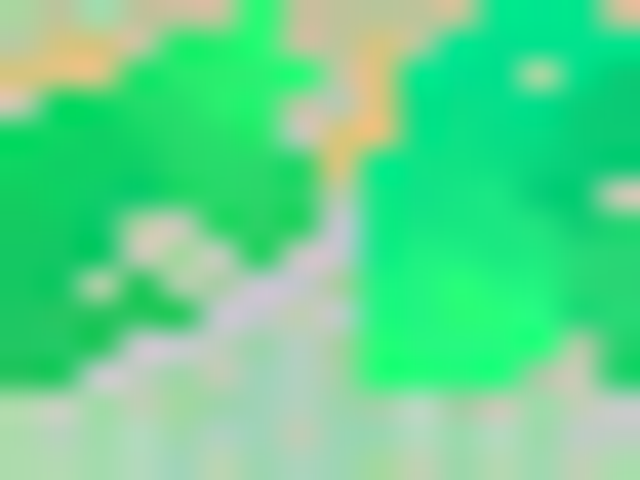

In [75]:
upscaled

In [76]:
image = image.convert("RGB")


In [77]:
blended = Image.blend(image, upscaled, alpha=0.6)  # 50% overlap
# blended.show()

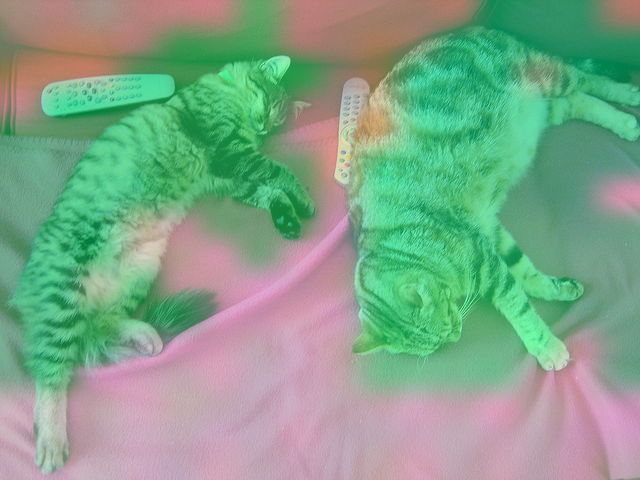

In [78]:
blended